# Model Selection and Evaluation - Part 1

When building supervised machine learning models, we need to solve two
problems:

1. **Model selection** - Finding the model that does as well as possible
on our learning task.

2. **Model evaluation** - Predicting **generalization error**, or the expected performance of our
model on unseen data.

Both are critical.  Without 1. we can't have an effective model and
without 2. we can't *know* if we have an effective model.

Once we have picked a particular machine learning algorithm, model
selection comes down to the problem of **hyperparameter** tuning.
Hyperparameters are parameters of our learning models that need to be
selected before the model can be learned.  Examples include the
maximum number of leaves in a decision tree or the number of hidden
units in a neural network classifier.

**WARNING:**  In the exercises below we will try several *BAD* approaches to model selection and evaluation.  These examples are not meant to illustrate the correct way of doing things, they are meant to show the consequences of doing things incorrectly. 


## Exercise 1 - Naive Model Selection

For now, let's focus entirely on model selection and disregard model
evaluation.  The following cell will load a data set and use a
decision tree regressor to fit a decision tree to the data. Try adjusting the `max_leaf_nodes` hyperparameter in order to minimize the MSE on the training set.

MSE: 0.0690


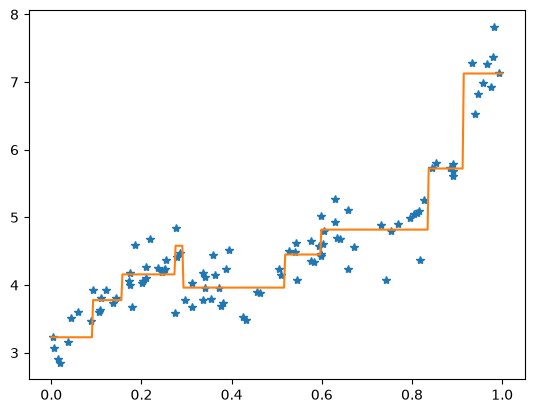

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import datasource

from sklearn.tree import DecisionTreeRegressor

# Grab our training data
source = datasource.DataSource()
X, y = source.gen_data(100, seed=100)

# Build a decision tree regressor
tree = DecisionTreeRegressor(max_leaf_nodes=9)
tree.fit(X, y)

# Evaluate the MSE of our decision tree on the training set
y_predict = tree.predict(X)
mse = np.sum((y - y_predict)**2) / y.size
print("MSE: {:.4f}".format(mse))

# Plot the fit.
plt.plot(X, y, '*', label="Training data")
x_plt = np.linspace(0, 1, 400).reshape(400, 1)
plt.plot(x_plt, tree.predict(x_plt))
plt.show()


### Questions

* What value of the hyperparameter resulted in the lowest MSE?
* Do you think that this MSE reflects how well this model will do on unseen data?  Why or why not?

### Answers: 

* .01
* The MSR reflects on seen data because it divides the dataset into seperate branches and evaluates each branch.

In the exercise above, you were able to tune the hyperparameters so as to *perfectly* fit the training data.  Now let's see what happens when we use this model on some new data drawn from the same underlying distribution:

In [4]:
X_new, y_new = source.gen_data(1000, seed=200)
y_new_predict = tree.predict(X_new)
mse = np.sum((y_new - y_new_predict)**2) / y_new.size
print("MSE: {:.4f}".format(mse))

MSE: 0.1216


## Exercise 2 - Using a Test Set for Hyperparameter Tuning and Evaluation

In the exercise above, you were able to perfectly fit a training data set, but that didn't tell you anything about how well your model would perform on unseen data.  We might address this by splitting our limited data into a training set and a test set.  This is illustrated in the cell below.

In [7]:
# Split our data into a training and testing set...
split_point = int(X.shape[0] * .8) # Use 80% of the data to train the model

X_train = X[0:split_point, :]
y_train = y[0:split_point]

X_test = X[split_point::, :]
y_test = y[split_point::]

# Build a decision tree regressor using the TRAINING set
tree = DecisionTreeRegressor(max_leaf_nodes=3)
tree.fit(X_train, y_train)

# Evaluate the MSE of our decision tree on the TESTING set 
y_test_predict = tree.predict(X_test)
mse = np.sum((y_test - y_test_predict)**2) / y_test.size
print("MSE: {:.4f}".format(mse))

for leaf_count in range(2, X_train.shape[0]+1):
    tree = DecisionTreeRegressor(max_leaf_nodes=leaf_count)
    tree.fit(X_train, y_train)
    y_test_predict = tree.predict(X_test)
    mse = np.sum((y_test - y_test_predict)**2) / y_test.size
    print("Leaf count: {}, MSE: {:.4f}".format(leaf_count, mse))
    


MSE: 0.0966
Leaf count: 2, MSE: 0.2301
Leaf count: 3, MSE: 0.0966
Leaf count: 4, MSE: 0.0785
Leaf count: 5, MSE: 0.0812
Leaf count: 6, MSE: 0.0784
Leaf count: 7, MSE: 0.0662
Leaf count: 8, MSE: 0.0944
Leaf count: 9, MSE: 0.1054
Leaf count: 10, MSE: 0.1129
Leaf count: 11, MSE: 0.1116
Leaf count: 12, MSE: 0.1132
Leaf count: 13, MSE: 0.1132
Leaf count: 14, MSE: 0.1135
Leaf count: 15, MSE: 0.1033
Leaf count: 16, MSE: 0.1207
Leaf count: 17, MSE: 0.1214
Leaf count: 18, MSE: 0.1153
Leaf count: 19, MSE: 0.1469
Leaf count: 20, MSE: 0.1420
Leaf count: 21, MSE: 0.1269
Leaf count: 22, MSE: 0.1269
Leaf count: 23, MSE: 0.1269
Leaf count: 24, MSE: 0.1269
Leaf count: 25, MSE: 0.1202
Leaf count: 26, MSE: 0.1104
Leaf count: 27, MSE: 0.1099
Leaf count: 28, MSE: 0.1229
Leaf count: 29, MSE: 0.1194
Leaf count: 30, MSE: 0.1292
Leaf count: 31, MSE: 0.1283
Leaf count: 32, MSE: 0.1567
Leaf count: 33, MSE: 0.1544
Leaf count: 34, MSE: 0.1553
Leaf count: 35, MSE: 0.1565
Leaf count: 36, MSE: 0.1565
Leaf count: 37, 

### Questions
* What hyperparameter settings gives us the lowest MSE on the testing data?  What is the MSE?  (I suggest writing a loop to systematically check all of the possible hyperparameter values. Bonus points for creating a plot with number of leaves vs. MSE.)
* Do you think *this* MSE will be reflective of how well our model will perform on unseen data? 

### Answers:

* 7 leaf nodes will produce the best results as the MSE will be at it's lowest with a MSE of .066
* Yes, as we are utilizing mutiple models to evaluate data.

Notice that in this example we are using our test set for *both* model selection and model evaluation.  We used it for model selection by searching for a hyperparameter setting that minimizes error on the test set.  We use it for model evaluation by using our test set error as an estimate of the expected error rate on unobserved data.

Let's see how our model does on some new, unobserved data drawn from the same distribution.  This cell will give us a good estimate of our *actual* generalization error.  (Note that in real-world problems we can't run a test like this because we don't have unlimited access to extra data that we can use to check our work.)

In [9]:
tree = DecisionTreeRegressor(max_leaf_nodes=7) # Put your best hyperparameter here!
tree.fit(X_train, y_train)

# Let's see how we do on unobserved data... 
X_new, y_new = source.gen_data(1000, seed=200)
y_new_predict = tree.predict(X_new)
mse = np.sum((y_new - y_new_predict)**2) / y_new.size
print("MSE: {:.4f}".format(mse))

MSE: 0.1200


### Questions

* Relative to Exercise 1, where we just looked for the model that best fit our training data, would you say that our train/test split was beneficial in terms of model selection, i.e. did we end up with a better model? Justify your answer.
* Would you say that our train/test split was beneficial in terms of model evaluation, i.e. were we able make a better prediction of our generalization error?  Justify your answer.
* Do you see any problems here in terms of model selection or evaluation?  How accurate was our prediction of generalization error?

### Answers:

* I would say that using the test set for both model selection and evaluation produced a more inaccurate model with a higher MSE score.
* Yes, as the test/train split provided a higher MSE score in comparison to the combined test and train
* Our model accuracy was at best around 99%, meaning it was accurate with it's dataset, although it may not be as accurate unless more information

### Click [here](model_selection_2.ipynb) to open the next page of exercises...